Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [86]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

## Raw Data Investigation

In [87]:
# Load the automobiles dataset
automobiles_df = pd.read_csv('automobile.txt')

In [88]:
automobiles_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [89]:
automobiles_df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [34]:
automobiles_df.nunique()

symboling              6
normalized-losses     52
make                  22
fuel-type              2
aspiration             2
num-of-doors           3
body-style             5
drive-wheels           3
engine-location        2
wheel-base            53
length                75
width                 44
height                49
curb-weight          171
engine-type            7
num-of-cylinders       7
engine-size           44
fuel-system            8
bore                  39
stroke                37
compression-ratio     32
horsepower            60
peak-rpm              24
city-mpg              29
highway-mpg           30
price                187
dtype: int64

In [35]:
for col in automobiles_df.columns:
    print(col)
    print(automobiles_df[col].unique())
    print("-" * 40)

symboling
[ 3  1  2  0 -1 -2]
----------------------------------------
normalized-losses
<StringArray>
[  '?', '164', '158', '192', '188', '121',  '98',  '81', '118', '148', '110',
 '145', '137', '101',  '78', '106',  '85', '107', '104', '113', '150', '129',
 '115',  '93', '142', '161', '153', '125', '128', '122', '103', '168', '108',
 '194', '231', '119', '154',  '74', '186',  '83', '102',  '89',  '87',  '77',
  '91', '134',  '65', '197',  '90',  '94', '256',  '95']
Length: 52, dtype: str
----------------------------------------
make
<StringArray>
[  'alfa-romero',          'audi',           'bmw',     'chevrolet',
         'dodge',         'honda',         'isuzu',        'jaguar',
         'mazda', 'mercedes-benz',       'mercury',    'mitsubishi',
        'nissan',        'peugot',      'plymouth',       'porsche',
       'renault',          'saab',        'subaru',        'toyota',
    'volkswagen',         'volvo']
Length: 22, dtype: str
----------------------------------------
f

In [90]:
automobiles_df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


## Handling "?" values

In [36]:
# Replacing "?" values as missing values so they can be seen and handled as missing values.
automobiles_df.replace('?', np.nan, inplace=True)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [37]:
missing_values = automobiles_df.isnull().sum()
missing_values[:]

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [38]:
# Dropping unneccesary columns
automobiles_df.drop(['normalized-losses', 'symboling'], axis=1, inplace=True)
automobiles_df.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


#### Remove any duplicate rows

In [39]:
print("Duplicates:", automobiles_df.duplicated().sum())

Duplicates: 0


#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [40]:
# Code here
before = len(automobiles_df)
automobiles_df = automobiles_df.dropna()
after = len(automobiles_df)

print(f"Rows removed: {before - after}")

Rows removed: 12


Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [41]:
# Code here
automobiles_df.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    str    
 1   fuel-type          193 non-null    str    
 2   aspiration         193 non-null    str    
 3   num-of-doors       193 non-null    str    
 4   body-style         193 non-null    str    
 5   drive-wheels       193 non-null    str    
 6   engine-location    193 non-null    str    
 7   wheel-base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb-weight        193 non-null    int64  
 12  engine-type        193 non-null    str    
 13  num-of-cylinders   193 non-null    str    
 14  engine-size        193 non-null    int64  
 15  fuel-system        193 non-null    str    
 16  bore               193 non-null    str    

In [42]:
# Changing columns with str types to int64 data types
Columns_int = ['horsepower', 'peak-rpm', 'price']
automobiles_df[Columns_int] = automobiles_df[Columns_int].astype(np.int64)

# Changing columns with str types to float64 data types
Columns_float = ['bore', 'stroke']
automobiles_df[Columns_float] = automobiles_df[Columns_float].astype(np.float64)

automobiles_df.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    str    
 1   fuel-type          193 non-null    str    
 2   aspiration         193 non-null    str    
 3   num-of-doors       193 non-null    str    
 4   body-style         193 non-null    str    
 5   drive-wheels       193 non-null    str    
 6   engine-location    193 non-null    str    
 7   wheel-base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb-weight        193 non-null    int64  
 12  engine-type        193 non-null    str    
 13  num-of-cylinders   193 non-null    str    
 14  engine-size        193 non-null    int64  
 15  fuel-system        193 non-null    str    
 16  bore               193 non-null    float64

### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [43]:
# Create a dataframe with all the cars in the "hatchback' category

hatchback_cars = automobiles_df[automobiles_df['body-style'] == 'hatchback']
hatchback_cars.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
18,chevrolet,gas,std,two,hatchback,fwd,front,88.4,141.1,60.3,...,61,2bbl,2.91,3.03,9.50,48,5100,47,53,5151
19,chevrolet,gas,std,two,hatchback,fwd,front,94.5,155.9,63.6,...,90,2bbl,3.03,3.11,9.60,70,5400,38,43,6295
21,dodge,gas,std,two,hatchback,fwd,front,93.7,157.3,63.8,...,90,2bbl,2.97,3.23,9.41,68,5500,37,41,5572
22,dodge,gas,std,two,hatchback,fwd,front,93.7,157.3,63.8,...,90,2bbl,2.97,3.23,9.40,68,5500,31,38,6377


### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

In [44]:
# Code here
automobiles_df.sort_values(by='price', ascending=False).head(5)

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
74,mercedes-benz,gas,std,two,hardtop,rwd,front,112.0,199.2,72.0,...,304,mpfi,3.80,3.35,8.0,184,4500,14,16,45400
16,bmw,gas,std,two,sedan,rwd,front,103.5,193.8,67.9,...,209,mpfi,3.62,3.39,8.0,182,5400,16,22,41315
73,mercedes-benz,gas,std,four,sedan,rwd,front,120.9,208.1,71.7,...,308,mpfi,3.80,3.35,8.0,184,4500,14,16,40960
128,porsche,gas,std,two,convertible,rwd,rear,89.5,168.9,65.0,...,194,mpfi,3.74,2.90,9.5,207,5900,17,25,37028
17,bmw,gas,std,four,sedan,rwd,front,110.0,197.0,70.9,...,209,mpfi,3.62,3.39,8.0,182,5400,15,20,36880


#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

In [46]:
# Code here
automobiles_df.groupby('make')['city-mpg'].mean().idxmax()

'chevrolet'

In [47]:
automobiles_df.groupby('make')['highway-mpg'].mean().idxmax()

'chevrolet'

#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

In [48]:
# Code here

automobiles_df.sort_values(by='engine-size', ascending=False).head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
49,jaguar,gas,std,two,sedan,rwd,front,102.0,191.7,70.6,...,326,mpfi,3.54,2.76,11.5,262,5000,13,17,36000
73,mercedes-benz,gas,std,four,sedan,rwd,front,120.9,208.1,71.7,...,308,mpfi,3.80,3.35,8.0,184,4500,14,16,40960
74,mercedes-benz,gas,std,two,hardtop,rwd,front,112.0,199.2,72.0,...,304,mpfi,3.80,3.35,8.0,184,4500,14,16,45400
47,jaguar,gas,std,four,sedan,rwd,front,113.0,199.6,69.6,...,258,mpfi,3.63,4.17,8.1,176,4750,15,19,32250
48,jaguar,gas,std,four,sedan,rwd,front,113.0,199.6,69.6,...,258,mpfi,3.63,4.17,8.1,176,4750,15,19,35550


#### Which vehicle manufacturer has the most car models in the dataset

In [49]:
# Code here

automobiles_df.groupby('make').size().idxmax()

'toyota'

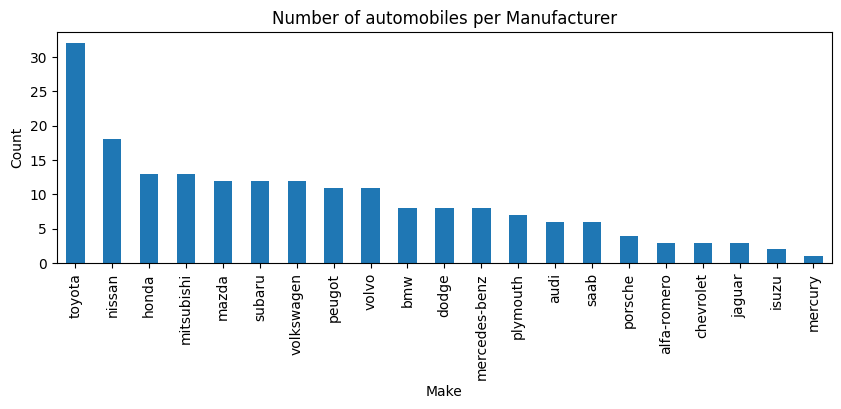

In [71]:
automobiles_df['make'].value_counts().plot(kind='bar', figsize=(10,3))
plt.title('Number of automobiles per Manufacturer')
plt.xlabel('Make')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.savefig("Number of automobiles per Manufacturer", dpi=300, bbox_inches="tight")
plt.show()

# Distribution

## Price Distribution

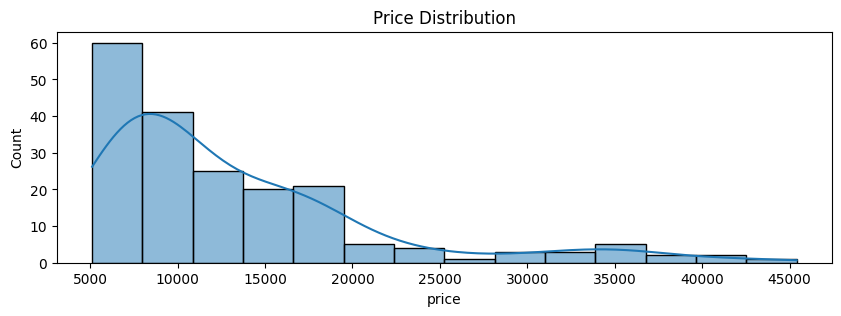

In [51]:
plt.figure(figsize=(10, 3))
sns.histplot(automobiles_df['price'], kde=True)
plt.title('Price Distribution')

plt.savefig("Price distribution", dpi=300, bbox_inches="tight")
plt.show()

## Fuel efficiency distribution

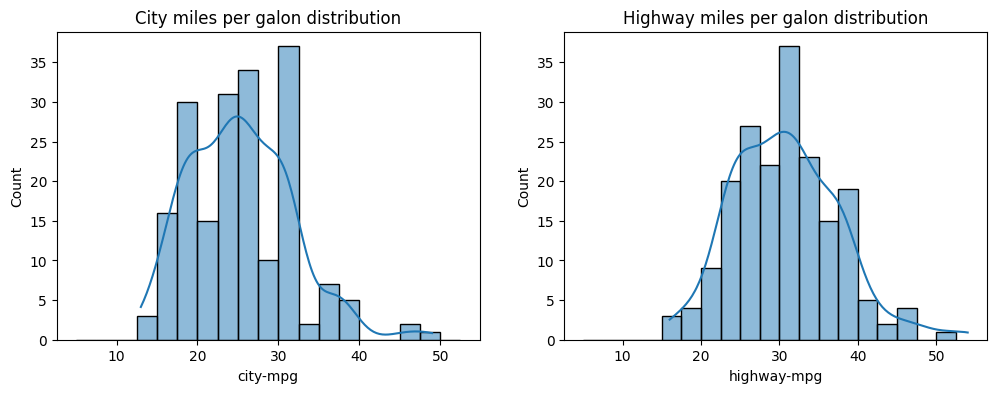

In [52]:
bins = np.arange(5, 55, 2.5)

fig, axes = plt.subplots(1, 2, figsize = (12,4))

sns.histplot(automobiles_df['city-mpg'], kde=True, bins=bins, ax=axes[0])
sns.histplot(automobiles_df['highway-mpg'], kde=True, bins=bins, ax=axes[1])
axes[0].set_title('City miles per galon distribution')
axes[1].set_title('Highway miles per galon distribution')

plt.savefig("Fuel efficiency distribution", dpi=300, bbox_inches="tight")
plt.show()

# Heatmap

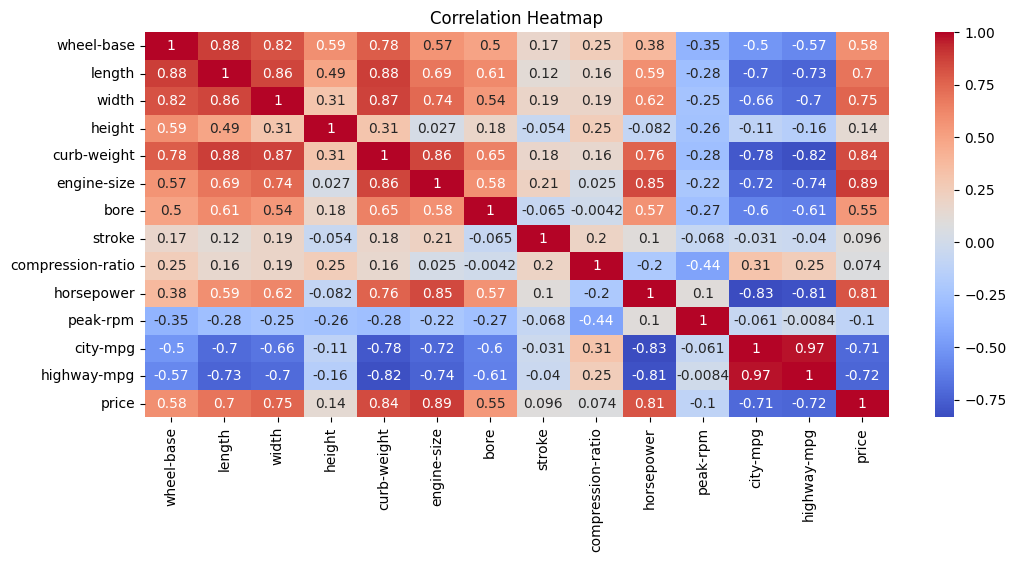

In [53]:
corr = automobiles_df.corr(numeric_only=True)
plt.figure(figsize=(12, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('Correlation Heatmap', dpi=300, bbox_inches="tight")

# Comparisons across groups

## Manufacturer

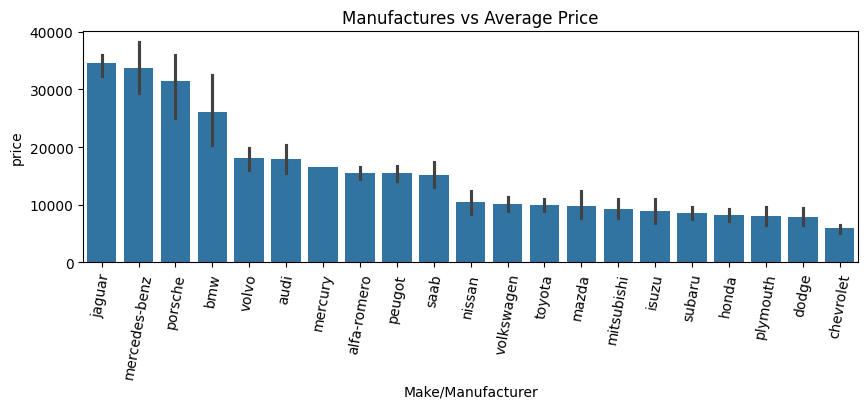

In [62]:
order=automobiles_df.groupby('make')['price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 3))
sns.barplot(data=automobiles_df, x='make', y='price', order=order)
plt.xticks(rotation=80)
plt.title('Manufactures vs Average Price')
plt.xlabel('Make/Manufacturer')

plt.savefig('Manufactures vs Average Price', dpi=300, bbox_inches="tight")
plt.show()

## Body Styles

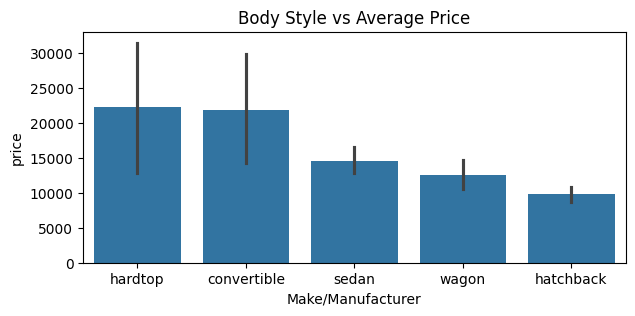

In [63]:
order=automobiles_df.groupby('body-style')['price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(7, 3))
sns.barplot(data=automobiles_df, x='body-style', y='price', order=order)
plt.title('Body Style vs Average Price')
plt.xlabel('Make/Manufacturer')

plt.savefig('Body Style vs Average Price', dpi=300, bbox_inches="tight")
plt.show()

# Relationships

## Price vs Fuel Efficiency

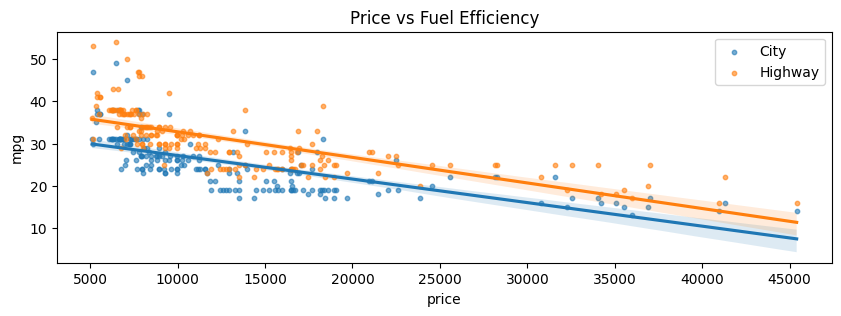

In [83]:
plt.figure(figsize=(10,3))

sns.regplot(data=automobiles_df, x='price', y='city-mpg', scatter_kws={'alpha': 0.6, 's': 10}, label='City')
sns.regplot(data=automobiles_df, x='price', y='highway-mpg', scatter_kws={'alpha':0.6, 's': 10}, label='Highway')

plt.title('Price vs Fuel Efficiency')
plt.ylabel('mpg')
plt.legend()

plt.savefig('Price vs Fuel Efficiency with Trend Lines', dpi=300, bbox_inches="tight")
plt.show()

## Price vs Engine Size

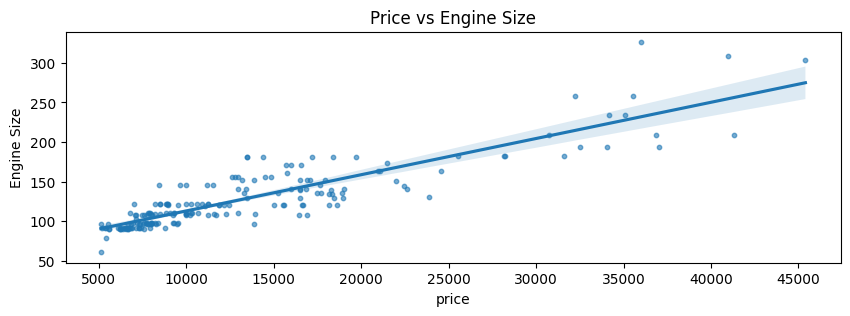

In [82]:
plt.figure(figsize=(10,3))

sns.regplot(data=automobiles_df, x='price', y='engine-size', scatter_kws={'alpha': 0.6, 's': 10})

plt.title('Price vs Engine Size')
plt.ylabel('Engine Size')

plt.savefig('Price vs Engine Size', dpi=300, bbox_inches="tight")
plt.show()